<a id="sec-top"></a>
# 🔧 Rossmann Store Sales — Feature Engineering

**Project:** Rossmann Sales Forecasting
**Notebook:** `02_feature_engineering.ipynb`
**Input:** `sales_daily` + `stores` tables (same source as `01_eda.ipynb`)
**Output:** a single clean, model-ready feature table saved to
`data/processed/features.parquet`

### 🎯 Purpose of this notebook
Turn the raw `sales_daily` + `stores` tables into a feature-rich table that
`03_modeling_classical.ipynb` and `04_modeling_lstm.ipynb` can load directly.
Every decision here follows directly from what we found in `01_eda.ipynb`
(seasonality, missing values, promo/holiday effects, store segmentation).

**Design choice:** lag and rolling-window features are computed in **SQL**
(window functions), since the database will serve this exact pattern in
production. Calendar encoding, string parsing, and target transforms are done
in **pandas**, since they're awkward or unnecessary to do in SQL. This mirrors
a realistic data-platform split: SQL for storage/aggregation, Python for
ML-specific transforms.

---

## 📑 Table of Contents
- [0. Setup](#sec-0)
- [1. Load Base Feature Set](#sec-1)
- [2. Handle Missing Values](#sec-2)
- [3. Calendar Features](#sec-3)
- [4. Competition Features](#sec-4)
- [5. Promo Features](#sec-5)
- [6. Lag Features (SQL Window Functions)](#sec-6)
- [7. Rolling Window Features (SQL Window Functions)](#sec-7)
- [8. Store Segmentation Features](#sec-8)
- [9. Target Transformation](#sec-9)
- [10. Chronological Train/Validation Split](#sec-10)
- [11. Handle Closed-Store Rows & Gaps](#sec-11)
- [12. Final Feature Table & Save](#sec-12)
- [13. Summary & Handoff Notes](#sec-13)

---

<a id="sec-0"></a>
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 100)

In [2]:
from sqlalchemy import create_engine

# Local SQLite for development. Swap for the Supabase DATABASE_URL when
# building the production feature pipeline for the API.
engine = create_engine("sqlite:///../data/processed/rossmann.db")

def run_query(query: str) -> pd.DataFrame:
    """Run a SQL query against `engine` and return the result as a DataFrame."""
    return pd.read_sql(query, engine)

---

<a id="sec-1"></a>
## 1. Load Base Feature Set

Pull `sales_daily` joined with `stores`, restricted to open days only (closed
days are handled separately in [Section 11](#sec-11)). This is the same shape
of query used in `01_eda.ipynb` Section 9.1, extended with all raw columns
we'll need for feature derivation.

In [3]:
base_query = """
SELECT
    sd.store_id,
    sd.date,
    sd.day_of_week,
    sd.sales,
    sd.customers,
    sd.open,
    sd.promo,
    sd.state_holiday,
    sd.school_holiday,
    s.store_type,
    s.assortment,
    s.competition_distance,
    s.competition_open_since_month,
    s.competition_open_since_year,
    s.promo2,
    s.promo2_since_week,
    s.promo2_since_year,
    s.promo_interval
FROM sales_daily sd
JOIN stores s ON sd.store_id = s.store_id
WHERE sd.open = 1
ORDER BY sd.store_id, sd.date;
"""

df = run_query(base_query)
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(844392, 18)


,store_id,date,day_of_week,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,2013-01-02,3,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,None
1,1,2013-01-03,4,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,None
2,1,2013-01-04,5,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,None
3,1,2013-01-05,6,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,None
4,1,2013-01-07,1,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,None


📝 **Note:** we filter to `open = 1` here because we're building demand-forecasting
features — a closed store's "sales" is trivially zero and would distort lag/rolling
averages if included. See [Section 11](#sec-11) for how this affects date continuity.

---

<a id="sec-2"></a>
## 2. Handle Missing Values

From EDA, `competition_distance`, `competition_open_since_month/year`, and the
`promo2_*` columns contain structural NaNs (not random missingness).

In [4]:
# Quick check before imputing
df[["competition_distance", "competition_open_since_month",
    "competition_open_since_year", "promo2_since_week",
    "promo2_since_year", "promo_interval"]].isnull().sum()

competition_distance              2186
competition_open_since_month    268619
competition_open_since_year     268619
promo2_since_week               423307
promo2_since_year               423307
promo_interval                  423307
dtype: int64

In [5]:
# competition_distance: NaN effectively means "no nearby competitor recorded".
# Impute with a large constant well beyond the observed max, so the model can
# distinguish "far away" from "no competitor" without losing the numeric type.
max_dist = df["competition_distance"].max()
FAR_AWAY_CONSTANT = max_dist * 1.5

df["competition_distance"] = df["competition_distance"].fillna(FAR_AWAY_CONSTANT)

# Flag whether a store originally had competitor info at all
df["has_competition_info"] = df["competition_distance"].notna().astype(int)

print(f"Imputed competition_distance NaNs with {FAR_AWAY_CONSTANT:.0f}")

Imputed competition_distance NaNs with 113790


In [6]:
# promo2_since_week/year and promo_interval are NaN exactly when promo2 = 0.
# No imputation needed here -- downstream features (Section 5) explicitly
# check `promo2 == 1` before using these columns, so NaNs are handled safely.
assert (df.loc[df["promo2"] == 0, "promo_interval"].isnull().all()), \
    "Expected promo_interval to be null whenever promo2 == 0"
print("Confirmed: promo2_* NaNs align with promo2 == 0 as expected.")

Confirmed: promo2_* NaNs align with promo2 == 0 as expected.


---

<a id="sec-3"></a>
## 3. Calendar Features

Derive date-based features, plus cyclical (sin/cos) encodings so day-of-week
and month don't get treated as a flat numeric scale (e.g. Sunday=7 and
Monday=1 are numerically far apart but are actually adjacent in the weekly
cycle).

In [7]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([6, 7]).astype(int)

# Cyclical encoding -- keeps the "distance" between Dec and Jan, or Sun and
# Mon, small instead of artificially large.
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7) # it is necessary for LSTM
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df[["date", "day_of_week", "day_of_week_sin", "day_of_week_cos",
    "month", "month_sin", "month_cos", "is_weekend"]].head()

,date,day_of_week,day_of_week_sin,day_of_week_cos,month,month_sin,month_cos,is_weekend
0,2013-01-02,3,0.433884,-0.900969,1,0.5,0.866025,0
1,2013-01-03,4,-0.433884,-0.900969,1,0.5,0.866025,0
2,2013-01-04,5,-0.974928,-0.222521,1,0.5,0.866025,0
3,2013-01-05,6,-0.781831,0.623490,1,0.5,0.866025,1
4,2013-01-07,1,0.781831,0.623490,1,0.5,0.866025,0


📝 **Insight:** verify visually that `day_of_week_sin`/`cos` trace out a smooth
circle when plotted against each other — confirms the cyclical encoding is
correct before relying on it in the LSTM input.

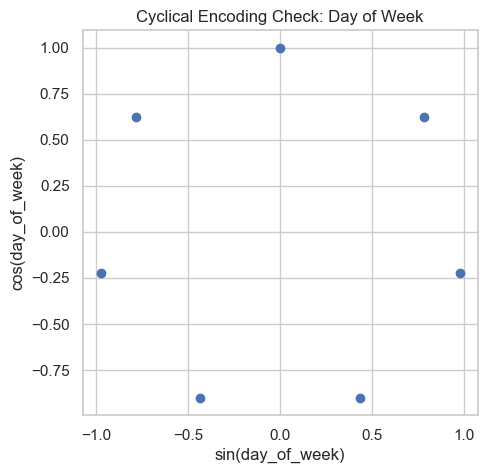

In [8]:
fig, ax = plt.subplots()
ax.scatter(df["day_of_week_sin"].drop_duplicates(), df["day_of_week_cos"].drop_duplicates())
ax.set_title("Cyclical Encoding Check: Day of Week")
ax.set_xlabel("sin(day_of_week)")
ax.set_ylabel("cos(day_of_week)")
ax.set_aspect("equal")
plt.show()

---

<a id="sec-4"></a>
## 4. Competition-Related Features

Derive how long a competitor has existed relative to each sales record's date.

In [9]:
def months_since_competition(row):
    """Months between competitor opening and the current row's date.
    Returns 0 if no competitor info, or if competitor opened after this date
    (shouldn't happen, but guards against negative values from data noise)."""
    if pd.isna(row["competition_open_since_year"]) or pd.isna(row["competition_open_since_month"]):
        return 0
    comp_date = pd.Timestamp(year=int(row["competition_open_since_year"]),
                              month=int(row["competition_open_since_month"]), day=1)
    months = (row["date"].year - comp_date.year) * 12 + (row["date"].month - comp_date.month)
    return max(months, 0)

df["months_since_competition_open"] = df.apply(months_since_competition, axis=1)
df[["date", "competition_open_since_month", "competition_open_since_year",
    "months_since_competition_open"]].head()

,date,competition_open_since_month,competition_open_since_year,months_since_competition_open
0,2013-01-02,9.0,2008.0,52
1,2013-01-03,9.0,2008.0,52
2,2013-01-04,9.0,2008.0,52
3,2013-01-05,9.0,2008.0,52
4,2013-01-07,9.0,2008.0,52


⚠️ **Performance note:** `.apply(..., axis=1)` is fine for a one-time feature
build but is slow on very large DataFrames. If this cell is too slow on your
full ~1M row table, consider a vectorized version using `pd.to_datetime` on
constructed year/month columns instead of a per-row Python function.

---

<a id="sec-5"></a>
## 5. Promo-Related Features

`Promo` (day-level) is already a clean binary column. `Promo2` needs parsing:
it's a store-level flag for a recurring promotion active only in specific
months (`promo_interval`, e.g. `"Jan,Apr,Jul,Oct"`), starting from a given
week/year.

In [10]:
MONTH_MAP = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
             7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

def is_promo2_active(row):
    """True if this row's date falls within an active Promo2 window for its store:
    Promo2 must be enabled, the promo must have already started (year/week check),
    and the row's month must be listed in promo_interval."""
    if row["promo2"] == 0 or pd.isna(row["promo_interval"]):
        return 0

    # Has the promo technically started yet? (compare by ISO year/week)
    iso_year, iso_week, _ = row["date"].isocalendar()
    if iso_year < row["promo2_since_year"]:
        return 0
    if iso_year == row["promo2_since_year"] and iso_week < row["promo2_since_week"]:
        return 0

    active_months = row["promo_interval"].split(",")
    return int(MONTH_MAP[row["month"]] in active_months)

df["is_promo2_active"] = df.apply(is_promo2_active, axis=1)
df[["date", "promo2", "promo_interval", "month", "is_promo2_active"]].query("promo2 == 1").head(10)

,date,promo2,promo_interval,month,is_promo2_active
781,2013-01-02,1,"Jan,Apr,Jul,Oct",1,1
782,2013-01-03,1,"Jan,Apr,Jul,Oct",1,1
783,2013-01-04,1,"Jan,Apr,Jul,Oct",1,1
784,2013-01-05,1,"Jan,Apr,Jul,Oct",1,1
785,2013-01-07,1,"Jan,Apr,Jul,Oct",1,1
786,2013-01-08,1,"Jan,Apr,Jul,Oct",1,1
787,2013-01-09,1,"Jan,Apr,Jul,Oct",1,1
788,2013-01-10,1,"Jan,Apr,Jul,Oct",1,1
789,2013-01-11,1,"Jan,Apr,Jul,Oct",1,1
790,2013-01-12,1,"Jan,Apr,Jul,Oct",1,1


In [11]:
# Flag the first day a (day-level) promo turns on for a store -- captures the
# "launch spike" separately from ongoing promo days.
df = df.sort_values(["store_id", "date"])
df["promo_start_flag"] = (
    (df["promo"] == 1) &
    (df.groupby("store_id")["promo"].shift(1).fillna(0) == 0)
).astype(int)

df[["store_id", "date", "promo", "promo_start_flag"]].query("promo_start_flag == 1").head()

,store_id,date,promo,promo_start_flag
4,1,2013-01-07,1,1
16,1,2013-01-21,1,1
28,1,2013-02-04,1,1
40,1,2013-02-18,1,1
52,1,2013-03-04,1,1


---

<a id="sec-6"></a>
## 6. Lag Features (SQL Window Functions)

Built with `LAG()`, the same pattern used in `01_eda.ipynb` Section 4.4.
Computed in SQL and merged back into the pandas feature table — this query is
also saved to `sql/feature_engineering.sql` as a standalone artifact.

⚠️ **No leakage:** each lag value only looks at *earlier* rows for the same
store (`PARTITION BY store_id ORDER BY date`), so nothing here uses
information from the future relative to the row being featured.

In [12]:
lag_query = """
SELECT
    store_id,
    date,
    LAG(sales, 1)  OVER (PARTITION BY store_id ORDER BY date) AS sales_lag_1,
    LAG(sales, 7)  OVER (PARTITION BY store_id ORDER BY date) AS sales_lag_7,
    LAG(sales, 14) OVER (PARTITION BY store_id ORDER BY date) AS sales_lag_14,
    LAG(sales, 28) OVER (PARTITION BY store_id ORDER BY date) AS sales_lag_28,
    LAG(customers, 7) OVER (PARTITION BY store_id ORDER BY date) AS customers_lag_7
FROM sales_daily
WHERE open = 1
ORDER BY store_id, date;
"""

lag_features = run_query(lag_query)
lag_features["date"] = pd.to_datetime(lag_features["date"])
lag_features.head(10)

,store_id,date,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,customers_lag_7
0,1,2013-01-02,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,5530.0,NaN,NaN,NaN,NaN
2,1,2013-01-04,4327.0,NaN,NaN,NaN,NaN
3,1,2013-01-05,4486.0,NaN,NaN,NaN,NaN
4,1,2013-01-07,4997.0,NaN,NaN,NaN,NaN
5,1,2013-01-08,7176.0,NaN,NaN,NaN,NaN
6,1,2013-01-09,5580.0,NaN,NaN,NaN,NaN
7,1,2013-01-10,5471.0,5530.0,NaN,NaN,668.0
8,1,2013-01-11,4892.0,4327.0,NaN,NaN,578.0
9,1,2013-01-12,4881.0,4486.0,NaN,NaN,619.0


In [13]:
df = df.merge(lag_features, on=["store_id", "date"], how="left")
print(df.shape)
df[["store_id", "date", "sales", "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28"]].head(10)

(844392, 37)


,store_id,date,sales,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28
0,1,2013-01-02,5530,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,5530.0,NaN,NaN,NaN
2,1,2013-01-04,4486,4327.0,NaN,NaN,NaN
3,1,2013-01-05,4997,4486.0,NaN,NaN,NaN
4,1,2013-01-07,7176,4997.0,NaN,NaN,NaN
5,1,2013-01-08,5580,7176.0,NaN,NaN,NaN
6,1,2013-01-09,5471,5580.0,NaN,NaN,NaN
7,1,2013-01-10,4892,5471.0,5530.0,NaN,NaN
8,1,2013-01-11,4881,4892.0,4327.0,NaN,NaN
9,1,2013-01-12,4952,4881.0,4486.0,NaN,NaN


---

<a id="sec-7"></a>
## 7. Rolling Window Features (SQL Window Functions)

Rolling mean/std/min/max over trailing windows, using the pattern from
`01_eda.ipynb` Section 4.3. `ROWS BETWEEN N PRECEDING AND 1 PRECEDING` is used
(not `CURRENT ROW`) so today's own sales value never leaks into its own
rolling feature — critical for forecasting features.

In [14]:
rolling_query = """
SELECT
    store_id,
    date,
    AVG(sales) OVER (
        PARTITION BY store_id ORDER BY date
        ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS sales_rolling_mean_7,
    AVG(sales) OVER (
        PARTITION BY store_id ORDER BY date
        ROWS BETWEEN 30 PRECEDING AND 1 PRECEDING
    ) AS sales_rolling_mean_30,
    MIN(sales) OVER (
        PARTITION BY store_id ORDER BY date
        ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS sales_rolling_min_7,
    MAX(sales) OVER (
        PARTITION BY store_id ORDER BY date
        ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS sales_rolling_max_7
FROM sales_daily
WHERE open = 1
ORDER BY store_id, date;
"""

rolling_features = run_query(rolling_query)
rolling_features["date"] = pd.to_datetime(rolling_features["date"])
rolling_features.head(10)

,store_id,date,sales_rolling_mean_7,sales_rolling_mean_30,sales_rolling_min_7,sales_rolling_max_7
0,1,2013-01-02,NaN,NaN,NaN,NaN
1,1,2013-01-03,5530.000000,5530.000000,5530.0,5530.0
2,1,2013-01-04,4928.500000,4928.500000,4327.0,5530.0
3,1,2013-01-05,4781.000000,4781.000000,4327.0,5530.0
4,1,2013-01-07,4835.000000,4835.000000,4327.0,5530.0
5,1,2013-01-08,5303.200000,5303.200000,4327.0,7176.0
6,1,2013-01-09,5349.333333,5349.333333,4327.0,7176.0
7,1,2013-01-10,5366.714286,5366.714286,4327.0,7176.0
8,1,2013-01-11,5275.571429,5307.375000,4327.0,7176.0
9,1,2013-01-12,5354.714286,5260.000000,4486.0,7176.0


In [15]:
# Rolling standard deviation isn't available as a single SQL window function
# in SQLite/Postgres directly -- compute it in pandas instead, using the same
# "exclude current row" logic (shift by 1 before rolling).
rolling_std = (
    df.sort_values(["store_id", "date"])
      .groupby("store_id")["sales"]
      .apply(lambda s: s.shift(1).rolling(7).std())
      .reset_index(level=0, drop=True)
)
df["sales_rolling_std_7"] = rolling_std

df = df.merge(rolling_features, on=["store_id", "date"], how="left")
print(df.shape)
df[["store_id", "date", "sales", "sales_rolling_mean_7",
    "sales_rolling_std_7", "sales_rolling_min_7", "sales_rolling_max_7"]].head(10)

(844392, 42)


,store_id,date,sales,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_min_7,sales_rolling_max_7
0,1,2013-01-02,5530,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,5530.000000,NaN,5530.0,5530.0
2,1,2013-01-04,4486,4928.500000,NaN,4327.0,5530.0
3,1,2013-01-05,4997,4781.000000,NaN,4327.0,5530.0
4,1,2013-01-07,7176,4835.000000,NaN,4327.0,5530.0
5,1,2013-01-08,5580,5303.200000,NaN,4327.0,7176.0
6,1,2013-01-09,5471,5349.333333,NaN,4327.0,7176.0
7,1,2013-01-10,4892,5366.714286,944.271803,4327.0,7176.0
8,1,2013-01-11,4881,5275.571429,956.594456,4327.0,7176.0
9,1,2013-01-12,4952,5354.714286,885.295754,4486.0,7176.0


---

<a id="sec-8"></a>
## 8. Store Segmentation Features

Encode categorical store attributes, and build a coarse `store_cluster` label
(from EDA Section 7.1/7.4) to support per-cluster modeling later.

In [16]:
# One-hot encode store_type and assortment for models that need numeric input (LSTM).
# Tree-based / classical models can alternatively use the label-encoded version.
df = pd.get_dummies(df, columns=["store_type", "assortment"], prefix=["store_type", "assortment"])

# Bucket competition distance the same way as EDA Section 7.5, as a categorical feature
df["competition_distance_bucket"] = pd.cut(
    df["competition_distance"],
    bins=[-1, 1000, 5000, 20000, np.inf],
    labels=["under_1km", "1_5km", "5_20km", "over_20km"]
)

df.filter(like="store_type").head()

,store_type_a,store_type_b,store_type_c,store_type_d
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


📝 **Store clustering (optional, for per-segment modeling):** if you plan to
train separate models per store segment (recommended in the project plan to
avoid 1000+ individual SARIMA models), define the cluster here, e.g. by
combining `store_type` + `assortment` + `competition_distance_bucket` into a
single `store_cluster` label, and save it as a lookup table alongside the
feature file for `03_modeling_classical.ipynb` to use.

---

<a id="sec-9"></a>
## 9. Target Transformation

From EDA Section 3.2, sales were right-skewed. Add a log-transformed target
alongside the raw one, so both can be tested in modeling.

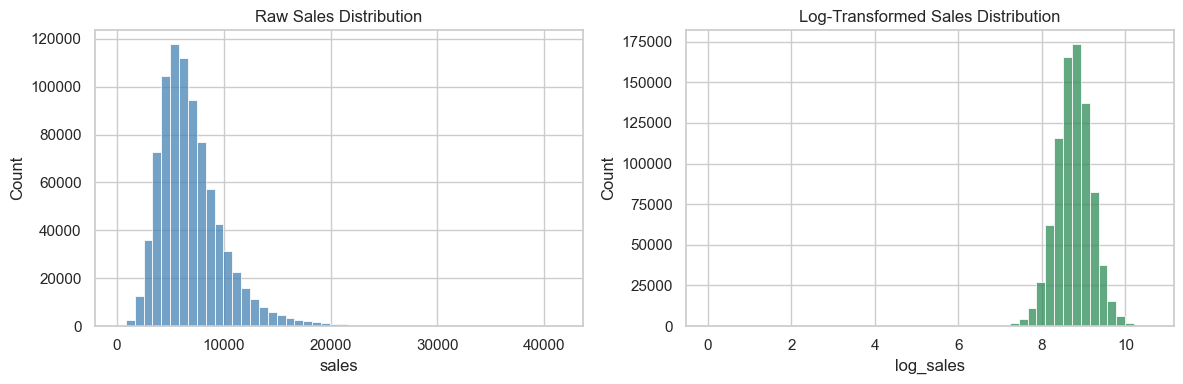

In [17]:
df["log_sales"] = np.log1p(df["sales"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["sales"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Raw Sales Distribution")
sns.histplot(df["log_sales"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("Log-Transformed Sales Distribution")
plt.tight_layout()
plt.show()

📝 **Insight:** the log-transformed distribution should look noticeably more
symmetric/normal than the raw one — if so, `log_sales` is worth testing as the
SARIMA/LSTM target, remembering to apply `np.expm1()` to convert predictions
back to the original sales scale before evaluating MAPE/RMSE in real units.

---

<a id="sec-10"></a>
## 10. Chronological Train/Validation Split

Time-series data must **never** be split randomly — that leaks future
information into training. Split strictly by date instead, and reuse this
exact boundary across every modeling notebook for consistency.

In [18]:
print("Full date range:", df["date"].min(), "to", df["date"].max())

# Hold out the final 6 weeks as validation, matching a realistic forecast horizon.
VALIDATION_WEEKS = 6
split_date = df["date"].max() - pd.Timedelta(weeks=VALIDATION_WEEKS)

print(f"Train/validation split date: {split_date.date()}")

df["split"] = np.where(df["date"] <= split_date, "train", "validation")
df["split"].value_counts()

Full date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Train/validation split date: 2015-06-19


split
train         804110
validation     40282
Name: count, dtype: int64

📝 **Important:** save `split_date` (or write it to a small config/metadata file)
so `03_modeling_classical.ipynb`, `04_modeling_lstm.ipynb`, and
`05_backtesting_evaluation.ipynb` all use the exact same boundary — this keeps
model comparisons fair and reproducible.

---

<a id="sec-11"></a>
## 11. Handle Closed-Store Rows & Date Gaps

Since we filtered to `open = 1` in Section 1, each store's time series now has
gaps on days it was closed. Lag/rolling features computed above are based on
row order *within the filtered data*, not on calendar continuity — meaning
`sales_lag_1` is really "sales on the last **open** day," which may be more
than 1 calendar day ago around closures (e.g. after a Sunday).

In [19]:
# Quantify how often a "lag_1" actually skips more than 1 calendar day
df_sorted = df.sort_values(["store_id", "date"])
df_sorted["prev_date"] = df_sorted.groupby("store_id")["date"].shift(1)
df_sorted["days_since_prev_open"] = (df_sorted["date"] - df_sorted["prev_date"]).dt.days

df_sorted["days_since_prev_open"].value_counts().sort_index().head(10)

days_since_prev_open
1.0     682742
2.0     150963
3.0       9299
4.0          5
5.0          3
6.0          4
7.0          2
8.0          4
9.0          2
10.0         5
Name: count, dtype: int64

📝 **Decision point:** a gap of 1 day is the normal case; a gap of 2 (e.g. after
a Sunday closure) is expected and generally fine to treat as "yesterday" for
lag purposes. If you see many larger gaps (multi-week closures from EDA
Section 8.2), consider excluding those specific stores from lag-based
features entirely, since their "lag_7" would actually reach back much further
than a real week. Document whichever choice you make here.

In [20]:
df["days_since_prev_open"] = df_sorted["days_since_prev_open"].values

---

<a id="sec-12"></a>
## 12. Final Feature Table & Save

Drop rows where lag/rolling features are NaN (the first N days of each
store's history, before enough prior data exists), then save the final table
for the modeling notebooks.

In [21]:
feature_cols = [c for c in df.columns if "lag" in c or "rolling" in c]
print("Rows before dropping lag/rolling NaNs:", len(df))

df_final = df.dropna(subset=feature_cols)
print("Rows after dropping lag/rolling NaNs:", len(df_final))
print(f"Dropped {len(df) - len(df_final)} rows ({(len(df) - len(df_final)) / len(df):.2%} of data)")

Rows before dropping lag/rolling NaNs: 844392
Rows after dropping lag/rolling NaNs: 813172
Dropped 31220 rows (3.70% of data)


In [22]:
print("Final feature table shape:", df_final.shape)
print("\nColumns:")
print(df_final.columns.tolist())

Final feature table shape: (813172, 51)

Columns:
['store_id', 'date', 'day_of_week', 'sales', 'customers', 'open', 'promo', 'state_holiday', 'school_holiday', 'competition_distance', 'competition_open_since_month', 'competition_open_since_year', 'promo2', 'promo2_since_week', 'promo2_since_year', 'promo_interval', 'has_competition_info', 'year', 'month', 'day', 'week_of_year', 'quarter', 'is_weekend', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'months_since_competition_open', 'is_promo2_active', 'promo_start_flag', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'customers_lag_7', 'sales_rolling_std_7', 'sales_rolling_mean_7', 'sales_rolling_mean_30', 'sales_rolling_min_7', 'sales_rolling_max_7', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'competition_distance_bucket', 'log_sales', 'split', 'days_since_prev_open']


In [23]:
# !pip install pyarrow

In [24]:
import os
os.makedirs("../data/processed", exist_ok=True)

output_path = "../data/processed/features.parquet"
df_final.to_parquet(output_path, index=False)
print(f"Saved final feature table to {output_path}")

Saved final feature table to ../data/processed/features.parquet


---

<a id="sec-13"></a>
## 13. Summary & Handoff Notes

*(Fill in after running against the full dataset.)*

### What was built
- **Calendar features:** year, month, day, week_of_year, quarter, is_weekend, cyclical day-of-week/month encodings
- **Competition features:** imputed `competition_distance`, `has_competition_info` flag, `months_since_competition_open`
- **Promo features:** `is_promo2_active`, `promo_start_flag`
- **Lag features (SQL):** sales lag 1/7/14/28 days, customers lag 7 days
- **Rolling features (SQL + pandas):** 7-day and 30-day rolling mean, 7-day rolling std/min/max — all excluding the current row to avoid leakage
- **Store segmentation:** one-hot encoded store_type/assortment, competition distance buckets
- **Target transform:** added `log_sales` alongside raw `sales`
- **Train/validation split:** chronological, split date = `[fill in from Section 10 output]`

### Key decisions & caveats
- [Note here how many rows were dropped due to missing lag history, from Section 12]
- [Note here how gaps around store closures were handled, from Section 11]
- [Note whether raw `sales` or `log_sales` looked more promising as the modeling target]

### Output
Final feature table saved to `data/processed/features.parquet` — load this
directly in `03_modeling_classical.ipynb` and `04_modeling_lstm.ipynb`:
```python
df = pd.read_parquet("../data/processed/features.parquet")
```

---
[⬆ Back to top](#sec-top)